In [1]:
import pandas as pd
import os
import yaml
from pathlib import Path 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
# Sample
preds = pd.read_parquet("/dccstor/gridfm/mlflow_alban_contingency/504276166362365184/0d2997d7a135403fad4297993d57bf64/artifacts/test/Texas2k_case1_2016summerpeak_predictions.parquet")
ac_residuals = pd.read_parquet("/dccstor/gridfm/mlflow_alban_contingency/504276166362365184/0d2997d7a135403fad4297993d57bf64/artifacts/test/Texas2k_case1_2016summerpeak_ac_bus_residuals.parquet")
dc_residuals = pd.read_parquet("/dccstor/gridfm/mlflow_alban_contingency/504276166362365184/0d2997d7a135403fad4297993d57bf64/artifacts/test/Texas2k_case1_2016summerpeak_dc_bus_residuals.parquet")

In [2]:
mlflow_run_dirs =  Path("/dccstor/gridfm/mlflow_alban_contingency/504276166362365184/")

In [3]:
k_vals = []
active_power_residuals = []
reactive_power_residuals = []
dc_avg_res = []
dc_bus_res = []

for run in mlflow_run_dirs.iterdir():
    if run.is_dir():
    # get k
        run_file = os.path.join(run, 'meta.yaml')
        with open(run_file, 'r') as file:
            config_data = yaml.safe_load(file)
            test_val = config_data.get('run_name')
            k_val = test_val.split('_')[1]
            k_vals.append(k_val)
            
        # get Pr and Qr
        preds_file = os.path.join(run, 'artifacts/test/Texas2k_case1_2016summerpeak_predictions.parquet')
        df = pd.read_parquet(preds_file)

        dc_bus_res_file = os.path.join(run, 'artifacts/test/Texas2k_case1_2016summerpeak_dc_bus_residuals.parquet')
        bus_dc_df = pd.read_parquet(dc_bus_res_file)
        bus_dc_val = bus_dc_df['DC active res. (MW)'].values.tolist()
        dc_bus_res.append(bus_dc_val)

        #pr = df.loc[df['Metric']=='Avg. active res. (MW)', 'Value'].item()
        pr = df['active res. (MW)'].values.tolist()
        active_power_residuals.append(pr)

        #qr = df.loc[df['Metric']=='Avg. reactive res. (MVar)', 'Value'].item()
        qr = df['reactive res. (MVar)'].values.tolist()
        reactive_power_residuals.append(qr)

        dc_file = os.path.join(run, 'artifacts/test/Texas2k_case1_2016summerpeak_ac_dc_metrics.csv')
        dc_df = pd.read_csv(dc_file)

        dc_pr = dc_df.loc[dc_df['Metric']=='DC Avg. active res. (MW)', 'Value'].item()
        dc_avg_res.append(dc_pr)


In [5]:
data = {
    "k": k_vals,
    "Active_power_residuals (MW)": active_power_residuals,
    "Reactive_power_residuals (MVar)": reactive_power_residuals,
    "DC_active_power_residuals (MW)": dc_avg_res,
    "DC_bus_residuals_active (MW)": dc_bus_res
}

df_plotting = pd.DataFrame(data)


In [7]:
df_plotting['k'] = pd.to_numeric(df_plotting['k'], errors='coerce')
df_plotting_sorted = df_plotting.sort_values(by='k', ascending=True)
df3 = df_plotting_sorted.set_index('k')


In [8]:
df3

,Active_power_residuals (MW),Reactive_power_residuals (MVar),DC_active_power_residuals (MW),DC_bus_residuals_active (MW)
k,,,,
1,"[0.10116767883300781, 0.04970550537109375, 0.2...","[0.030233383178710938, 0.024251699447631836, 0...",0.607205,"[0.1795870428267925, 0.12121805467495861, 0.22..."
2,"[0.10926437377929688, 0.00757598876953125, 0.0...","[0.018650054931640625, 0.003537416458129883, 0...",0.607272,"[0.36296585445334983, 0.12306274887401436, 0.2..."
3,"[0.09341621398925781, 0.04303741455078125, 0.1...","[0.021033763885498047, 0.0149688720703125, 0.0...",0.607665,"[0.30861453547709417, 0.12404613985619051, 0.2..."
4,"[0.016534805297851562, 0.004576683044433594, 0...","[0.004519939422607422, 0.0007648468017578125, ...",0.607942,"[0.21302980287249262, 0.08549713623141919, 0.2..."
5,"[0.039493560791015625, 0.0059871673583984375, ...","[0.03488731384277344, 0.003993988037109375, 0....",0.608439,"[0.3798978410672973, 0.1548237151161569, 0.431..."
6,"[3.1469249725341797, 0.18691349029541016, 3.83...","[0.4221954345703125, 0.02700519561767578, 0.47...",0.608210,"[0.2509918096622954, 0.11032568625026862, 0.23..."
7,"[0.10675048828125, 0.008928298950195312, 0.172...","[0.04172039031982422, 0.008178234100341797, 0....",0.608794,"[0.220200903846683, 0.09484898746878123, 0.118..."
8,"[0.16330528259277344, 0.018837928771972656, 0....","[0.039478302001953125, 0.009325981140136719, 0...",0.608609,"[0.14499082027041865, 0.09638490900352714, 0.2..."
9,"[0.06209754943847656, 0.0072078704833984375, 0...","[0.027165889739990234, 0.0004909038543701172, ...",0.609224,"[0.13244244550537587, 0.08264494448042825, 0.1..."


/tmp/ipykernel_3051404/3283565636.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, showfliers=False, patch_artist=True,


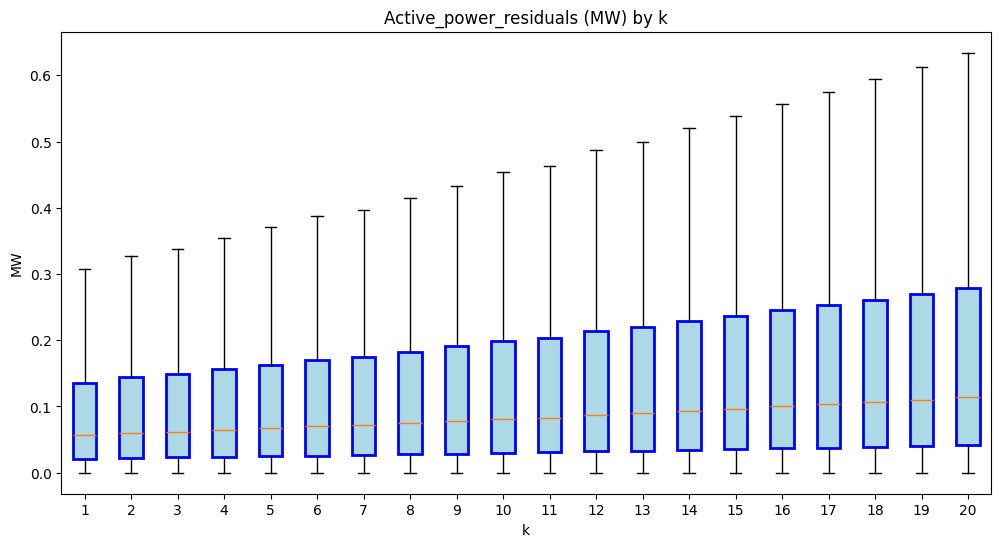

In [ ]:
# Create a list of the distribution lists
data_to_plot = df3['Active_power_residuals (MW)'].tolist()
labels = df3.index.tolist()

box_props = dict(facecolor='lightblue', color='blue', linewidth=2)

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=labels, showfliers=False, patch_artist=True,
            boxprops=box_props)

plt.title('Active_power_residuals (MW) by k')
plt.xlabel('k')
plt.ylabel('MW')
#plt.yscale('log') 
plt.show()

/tmp/ipykernel_3051404/544195504.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=labels, showfliers=False, patch_artist=True,


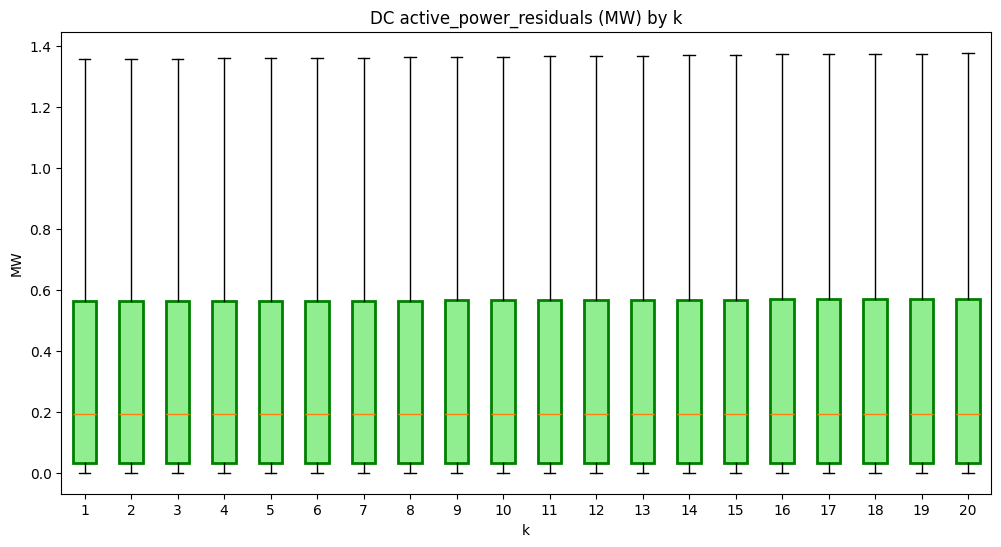

In [ ]:
data_to_plot = df3['DC_bus_residuals_active (MW)'].tolist()
labels = df3.index.tolist()

box_props = dict(facecolor='lightgreen', color='green', linewidth=2)

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=labels, showfliers=False, patch_artist=True,
            boxprops=box_props)

plt.title('DC active_power_residuals (MW) by k')
plt.xlabel('k')
plt.ylabel('MW')
#plt.yscale('log') 
plt.show()

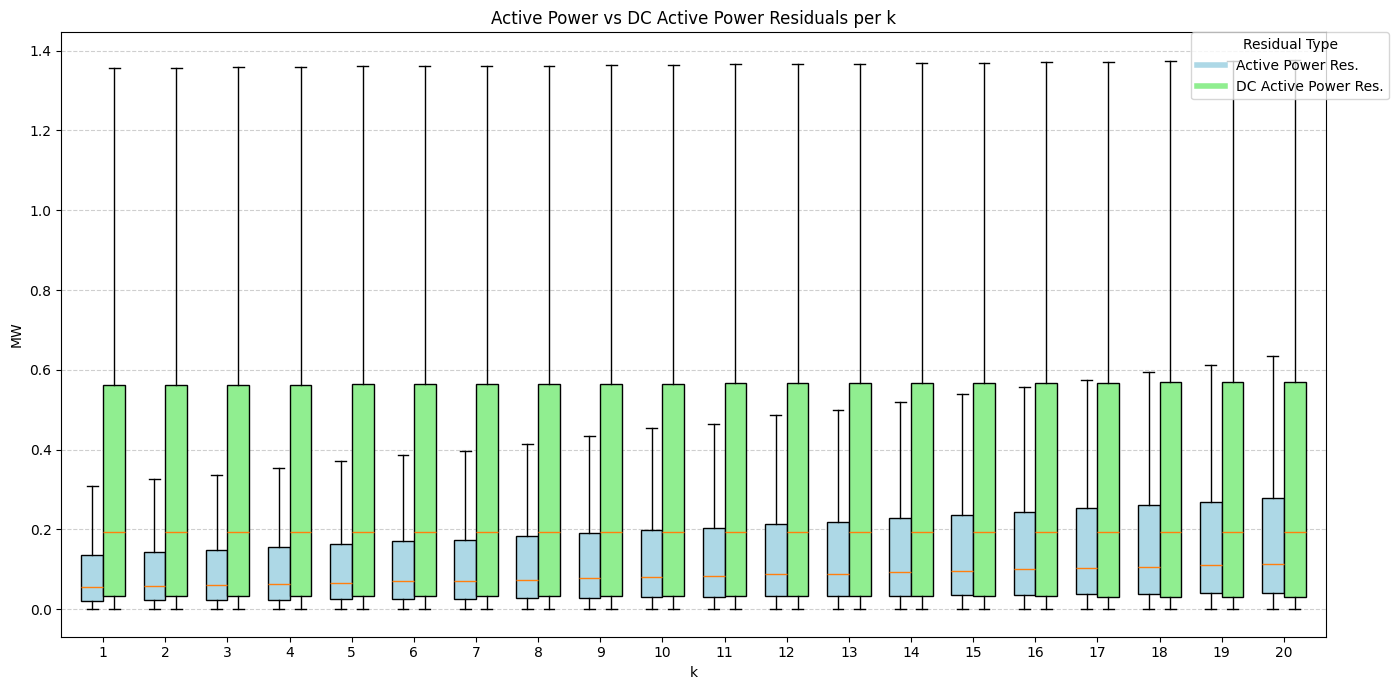

In [12]:
# PLot same axes

k_values = df3.index.values
n_groups = len(k_values)
width = 0.35  # Width of each box

plt.figure(figsize=(14, 7))

# Positions
bp1 = plt.boxplot(df3['Active_power_residuals (MW)'].tolist(), 
                  positions=np.arange(n_groups) - width/2, 
                  widths=width, patch_artist=True, showfliers=False)

bp2 = plt.boxplot(df3['DC_bus_residuals_active (MW)'].tolist(), 
                  positions=np.arange(n_groups) + width/2, 
                  widths=width, patch_artist=True, showfliers=False)

for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')


plt.xticks(np.arange(n_groups), k_values)
plt.xlabel('k')
plt.ylabel('MW')
plt.title('Active Power vs DC Active Power Residuals per k')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='lightblue', lw=4, label='Active Power Res.'),
                   Line2D([0], [0], color='lightgreen', lw=4, label='DC Active Power Res.')]
plt.legend(handles=legend_elements, title='Residual Type', bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.6)
#plt.yscale('log')
plt.tight_layout()
plt.show()



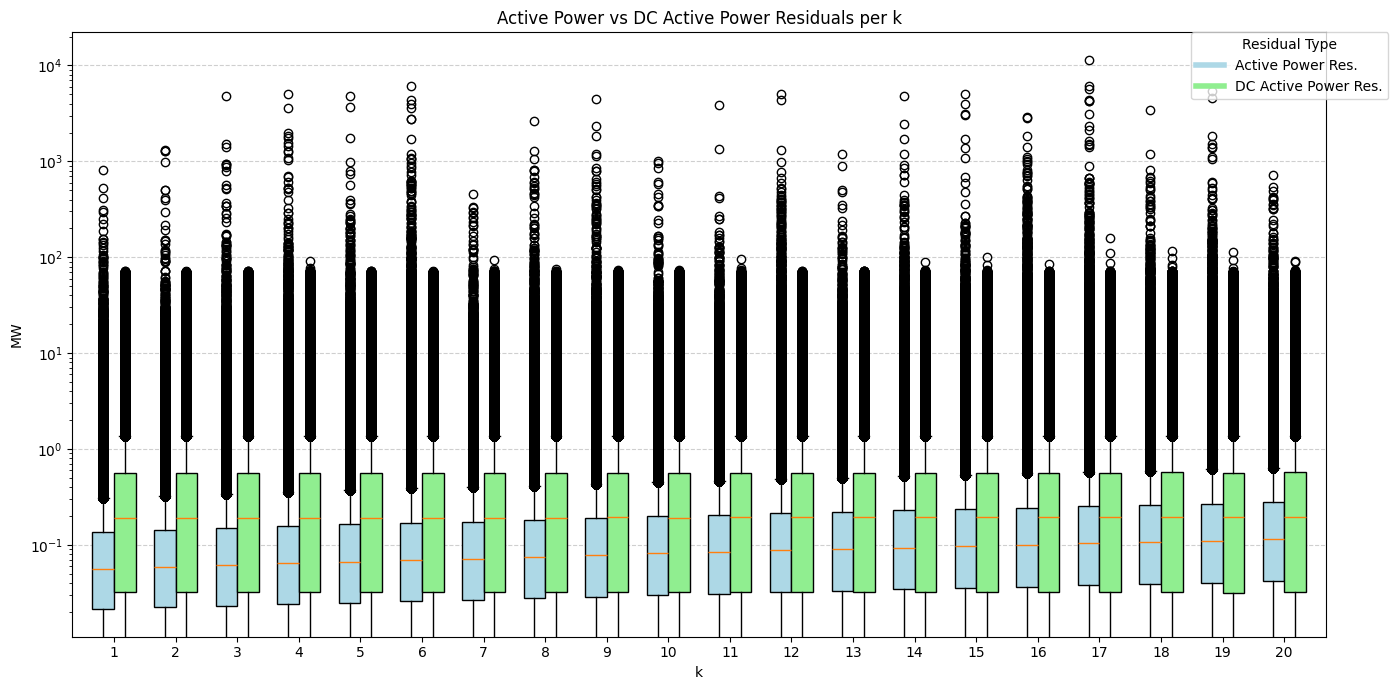

In [13]:
# Show outliers - log scale

k_values = df3.index.values
n_groups = len(k_values)
width = 0.35  # Width of each box

plt.figure(figsize=(14, 7))

# Positions
bp1 = plt.boxplot(df3['Active_power_residuals (MW)'].tolist(), 
                  positions=np.arange(n_groups) - width/2, 
                  widths=width, patch_artist=True, showfliers=True)

bp2 = plt.boxplot(df3['DC_bus_residuals_active (MW)'].tolist(), 
                  positions=np.arange(n_groups) + width/2, 
                  widths=width, patch_artist=True, showfliers=True)

for patch in bp1['boxes']:
    patch.set_facecolor('lightblue')
for patch in bp2['boxes']:
    patch.set_facecolor('lightgreen')


plt.xticks(np.arange(n_groups), k_values)
plt.xlabel('k')
plt.ylabel('MW')
plt.title('Active Power vs DC Active Power Residuals per k')

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='lightblue', lw=4, label='Active Power Res.'),
                   Line2D([0], [0], color='lightgreen', lw=4, label='DC Active Power Res.')]
plt.legend(handles=legend_elements, title='Residual Type', bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yscale('log')
plt.tight_layout()
plt.show()

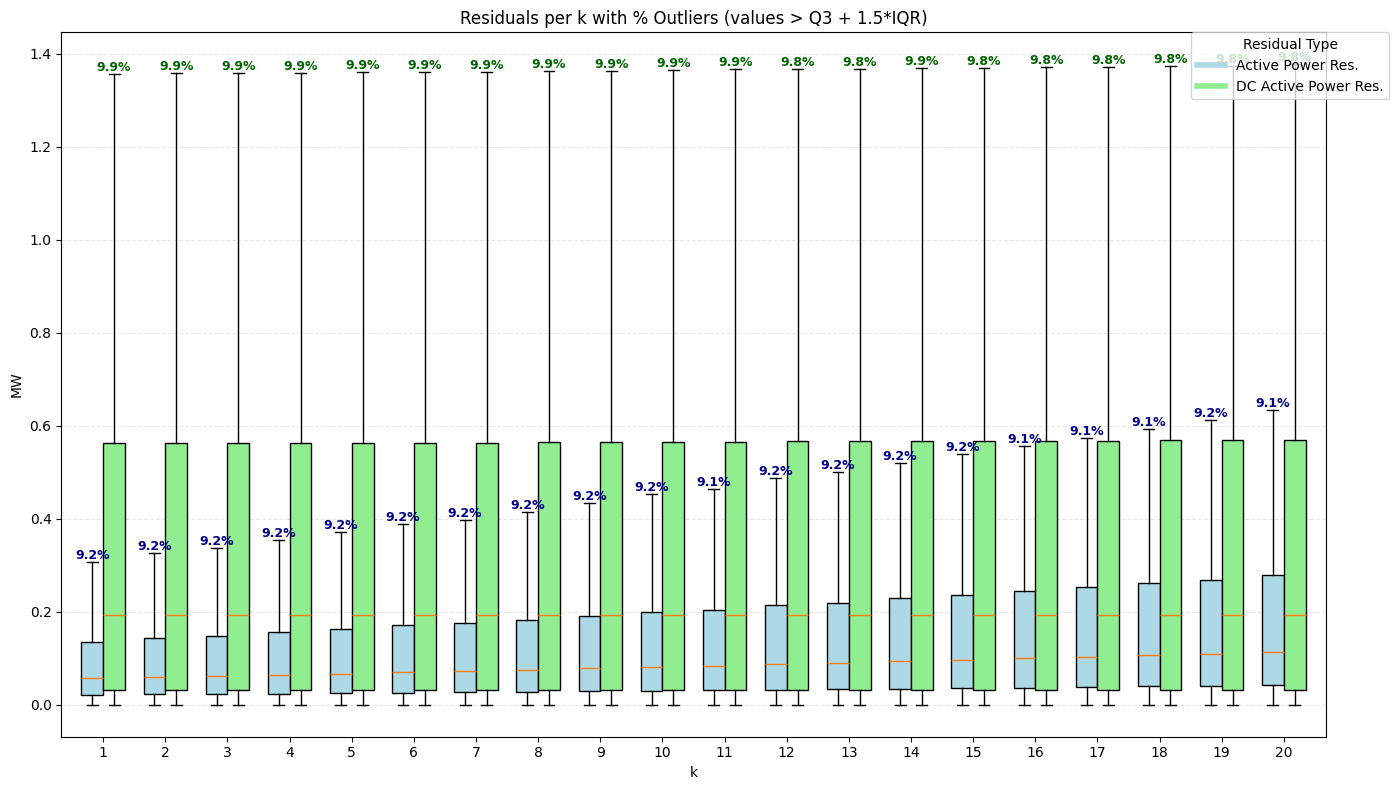

In [14]:
# With outlier %s -  used AI mode
k_values = df3.index.values
n_groups = len(k_values)
width = 0.35 

plt.figure(figsize=(14, 8))

data1 = df3['Active_power_residuals (MW)'].tolist()
data2 = df3['DC_bus_residuals_active (MW)'].tolist()


bp1 = plt.boxplot(data1, positions=np.arange(n_groups) - width/2, 
                  widths=width, patch_artist=True, showfliers=False)

bp2 = plt.boxplot(data2, positions=np.arange(n_groups) + width/2, 
                  widths=width, patch_artist=True, showfliers=False)


def add_outlier_labels(data_list, boxplot_obj, color):
    # 'whiskers' in boxplot_obj are in pairs: [bottom, top, bottom, top...]
    top_whiskers = boxplot_obj['whiskers'][1::2]
    
    for i, (data, whisker) in enumerate(zip(data_list, top_whiskers)):
        # Convert to numpy for math; ignore NaNs
        d = np.array(data)
        d = d[~np.isnan(d)]
        
        if len(d) == 0: continue
        
        # Calculate the actual Upper Fence (Q3 + 1.5*IQR)
        q1, q3 = np.percentile(d, [25, 75])
        iqr = q3 - q1
        upper = q3 + 1.5 * iqr
        
        # Calculate percentage of outliers
        outliers = d[d > upper]
        pct = (len(outliers) / len(d)) * 100
        
        # Get position for the text (top of the whisker)
        x = whisker.get_xdata()[0]
        y = whisker.get_ydata()[1] # The 'top' end of the whisker
        
        if pct > 0:
            plt.text(x, y, f'{pct:.1f}%', ha='center', va='bottom', 
                     fontsize=9, color=color, fontweight='bold')


for patch in bp1['boxes']: patch.set_facecolor('lightblue')
for patch in bp2['boxes']: patch.set_facecolor('lightgreen')

add_outlier_labels(data1, bp1, 'darkblue')
add_outlier_labels(data2, bp2, 'darkgreen')


plt.xticks(np.arange(n_groups), k_values)
plt.xlabel('k')
plt.ylabel('MW')
plt.title('Residuals per k with % Outliers (values > Q3 + 1.5*IQR)')

# Custom Legend
from matplotlib.lines import Line2D
plt.legend(handles=[
    Line2D([0], [0], color='lightblue', lw=4, label='Active Power Res.'),
    Line2D([0], [0], color='lightgreen', lw=4, label='DC Active Power Res.')
], title='Residual Type', bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0.)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()